In [2]:
import os
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import seaborn as sns
from getdist import plots, MCSamples

from shear_psf_leakage.rho_tau_stat import RhoStat, TauStat, PSFErrorFit

plt.style.use(
    "./matplotlib_config/paper.mplstyle"
)

plt.rcParams["text.usetex"] = True

sns.set_palette("husl")

%matplotlib inline

In [15]:
base_dir = "/home/guerrini/sp_validation/notebooks/cosmo_val/output/rho_tau_stats/"

versions = ["SP_v1.4.6", "SP_v1.4.6_leak_corr"]
labels = ["No leakage correction", "With leakage correction"]
colors = ["C0", "C1"]

In [16]:
samples = []
for ver in versions:
    sample = np.load(f"{base_dir}/samples_{ver}.npy")
    samples.append(
        sample[:, :2]  # Assuming the first two columns are the parameters of interest
    )

In [18]:
chains = []
for i, ver in enumerate(versions):
    chains.append(
        MCSamples(
            samples=samples[i],
            names=["\alpha", "\beta"],
            labels=[r"\alpha", r"\beta"],
            label=labels[i],
        )
    )

Removed no burn in
Removed no burn in


/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/getdist/plots.py:3347: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.fig.savefig(fname, bbox_extra_artists=self.extra_artists, bbox_inches='tight', **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/home/guerrini/.conda/envs/sp_validation_3.11/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


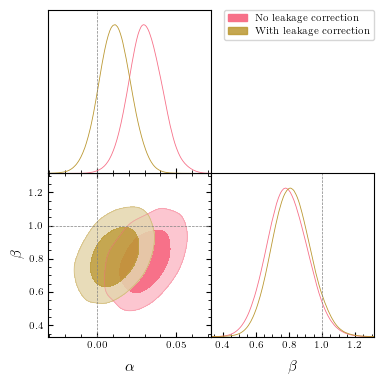

In [36]:
g = plots.get_subplot_plotter()

g.settings.legend_fontsize = 10
g.settings.axes_fontsize=10

markers = {
    "\alpha": 0.0,
    "\beta": 1.0,
}

line_args = [
    {'color': colors[i]} for i in range(len(versions))
]
g.triangle_plot(
    chains,
    filled=True,
    legend_labels=labels,
    legend_loc="upper right",
    line_args=line_args,
    contour_colors=colors,
    markers=markers
)

ax = g.get_axes(ax=(1, 0))
ax.minorticks_on()
ax = g.get_axes(ax=(1, 1))
ax.minorticks_on()
ax.get_yaxis().set_visible(False)
g.export("./plots/psf_leakage_prior.pdf")